In [2]:
library(tidyverse)
library(ape)
library(TreeSim)
library(phytools)
library(phylolm)
library(TreeTools)
library(tibble)
library(dplyr)
library(readr)
library(data.table)
library(gridExtra)
library(svglite)

### 1. Helper functions to create branch lengths for phylogenetic trees

In [3]:
# helper function to create the branch lengths for a tree with n tips

branch_lengths <- function(n, mu, r) {
    set.seed(r)
    branch_lengths = rexp(2 * (n - 1), rate = mu)
    return(branch_lengths)
}

### 2. Testing the scaling effect

In [4]:
num_rep = 500
n_tips = 2 ** c(3:10)
n_PCs = n_tips / 2 - 1
n_PCs[n_PCs > 50] = 50
n_size = length(n_tips)
n_rows = num_rep * (sum(n_PCs) + n_size) * 2

In [5]:
# Pectinate Trees

p_vals_PC_pectinate = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = PectinateTree(n_tip)
        tree$edge.length = branch_lengths(n_tip, 1, i)
        tree$root.edge=0
        PCs = eigen(vcv(tree))$vectors

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
        rownames(all_data) = rownames(BM)
    
        for (j in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            tryCatch({
                cur_lm = lm(cur_formula,data=all_data)
                cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
                p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                  "method" = "lm", "tips" = n_tip)]
                }, error = function(e) {
                p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                  "method" = "lm", "tips" = n_tip)]
                })
            
            counter = counter + 1
        
            tryCatch({
                cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
                cur_p = summary(cur_lm)$coefficients["X","p.value"]
                p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                                  "method" = "phylolm", "tips" = n_tip)]
                }, error = function(e) {
                p_vals_PC_pectinate[counter, `:=`("PCs" = j - 1, "p.value" = NA, 
                                                  "method" = "phylolm", "tips" = n_tip)]
                })
            
            counter = counter + 1
        }
    }
    
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [6]:
p_vals_PC_summary_pectinate = p_vals_PC_pectinate %>% # filter(PCs <= 35) %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_pectinate = as.data.table(p_vals_PC_summary_pectinate) 
p_vals_PC_summary_pectinate$tips = factor(p_vals_PC_summary_pectinate$tips)
p_vals_PC_summary_pectinate$method = factor(p_vals_PC_summary_pectinate$method)

In [7]:
# Balanced Trees

p_vals_PC_balanced = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = BalancedTree(n_tip)
        tree$edge.length = branch_lengths(n_tip, 1, i)
        tree$root.edge=0
        PCs = eigen(vcv(tree))$vectors

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
        rownames(all_data) = rownames(BM)
    
        for (j in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_balanced[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                             "method" = "lm", "tips" = n_tip)]
            
            counter = counter + 1
        
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_balanced[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                             "method" = "phylolm", "tips" = n_tip)]
            
            counter = counter + 1
        }
    }
    
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [8]:
p_vals_PC_summary_balanced = p_vals_PC_balanced %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_balanced = as.data.table(p_vals_PC_summary_balanced) 
p_vals_PC_summary_balanced$tips = factor(p_vals_PC_summary_balanced$tips)
p_vals_PC_summary_balanced$method = factor(p_vals_PC_summary_balanced$method)

In [9]:
# Coalescent Trees

p_vals_PC_coal = data.table(
    PCs=numeric(n_rows),
    p.value=numeric(n_rows), 
    method=character(n_rows), 
    tips=numeric(n_rows)
)

counter = 1

for (l in 1:n_size) {
    
    n_tip = n_tips[l]
    num_PC = n_PCs[l]
    message("Testing for size number", l, ":", n_tip, "tips")

    for (i in 1:num_rep) {
        if (i %% 50 == 0) {message(i)}
        
        set.seed(i)
    
        tree = rcoal(n_tip)
        tree$root.edge=0
        PCs = eigen(vcv(tree))$vectors

        colnames(PCs) = paste0("PC_",1:ncol(PCs))
        PCs = as_tibble(PCs)

        PC_sets = lapply(1:num_PC,function(i){paste0("PC_",1:i)})
        PC_sets = c("1",PC_sets)   
    
        BM = fastBM(tree,1,nsim=2)
        X = BM[,1]
        Y = BM[,2]
    
        all_data = as.data.frame(bind_cols(tibble(X = X, Y = Y),PCs))
    
        rownames(all_data) = rownames(BM)
    
        for (j in 1:length(PC_sets)) {
            cur_formula = as.formula(paste(c("Y ~ X", PC_sets[[j]]),collapse=" + "))
        
            cur_lm = lm(cur_formula,data=all_data)
            cur_p = summary(cur_lm)$coefficients["X","Pr(>|t|)"]
            p_vals_PC_coal[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                         "method" = "lm", "tips" = n_tip)]
            
            counter = counter + 1
        
            cur_lm = phylolm(cur_formula,data=all_data,phy=tree)
            cur_p = summary(cur_lm)$coefficients["X","p.value"]
            p_vals_PC_coal[counter, `:=`("PCs" = j - 1, "p.value" = cur_p, 
                                         "method" = "phylolm", "tips" = n_tip)]
            
            counter = counter + 1
        }
    }
    
}

Testing for size number1:8tips

50

100

150

200

250

300

350

400

450

500

Testing for size number2:16tips

50

100

150

200

250

300

350

400

450

500

Testing for size number3:32tips

50

100

150

200

250

300

350

400

450

500

Testing for size number4:64tips

50

100

150

200

250

300

350

400

450

500

Testing for size number5:128tips

50

100

150

200

250

300

350

400

450

500

Testing for size number6:256tips

50

100

150

200

250

300

350

400

450

500

Testing for size number7:512tips

50

100

150

200

250

300

350

400

450

500

Testing for size number8:1024tips

50

100

150

200

250

300

350

400

450

500



In [10]:
p_vals_PC_summary_coal = p_vals_PC_coal %>%
  group_by(method, PCs, tips) %>%
  summarise(FPR = mean(p.value<0.05), .groups = "drop") %>%
  mutate(method=ifelse(method=="phylolm","PGLS","OLS"))

p_vals_PC_summary_coal = as.data.table(p_vals_PC_summary_coal) 
p_vals_PC_summary_coal$tips = factor(p_vals_PC_summary_coal$tips)
p_vals_PC_summary_coal$method = factor(p_vals_PC_summary_coal$method)

### 3. Plotting

In [15]:
plot_1 <- p_vals_PC_summary_pectinate %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8), legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm"),
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

In [16]:
plot_2 <- p_vals_PC_summary_balanced %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8), legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm"),
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

In [13]:
plot_3 <- p_vals_PC_summary_coal %>% 
  ggplot(aes(PCs,FPR)) +
  geom_line(aes(color = tips, linetype = method), linewidth=2) +
  theme_classic(base_size=20) +
  xlab("Number of eigenvectors") +
  ylab("Fraction of significant tests") +
  geom_hline(yintercept=0.05,lty=2) +
  theme(legend.position=c(.85,.8), legend.spacing.y = unit(1,"pt"), 
        legend.key.width = unit(2, "cm"),
        axis.title.x = element_text(size = 24), axis.title.y = element_text(size = 24), 
        axis.text.x = element_text(size = 18), axis.text.y = element_text(size = 18),
        legend.title = element_text(size = 24), legend.text = element_text(size = 18)) +
  scale_color_manual(values=c("#332288","#88CCEE","#44AA99","#117733",
                              "#999933","#DDCC77", "#CC6677","#882255"), 
                     breaks = c("8", "16","32", "64", "128", "256", "512", "1024")) +
  scale_linetype_manual(values = c("solid", "twodash"), breaks = c("OLS", "PGLS"))

TableGrob (1 x 1) "arrange": 1 grobs
  z     cells    name            grob
1 1 (1-1,1-1) arrange gtable[arrange]

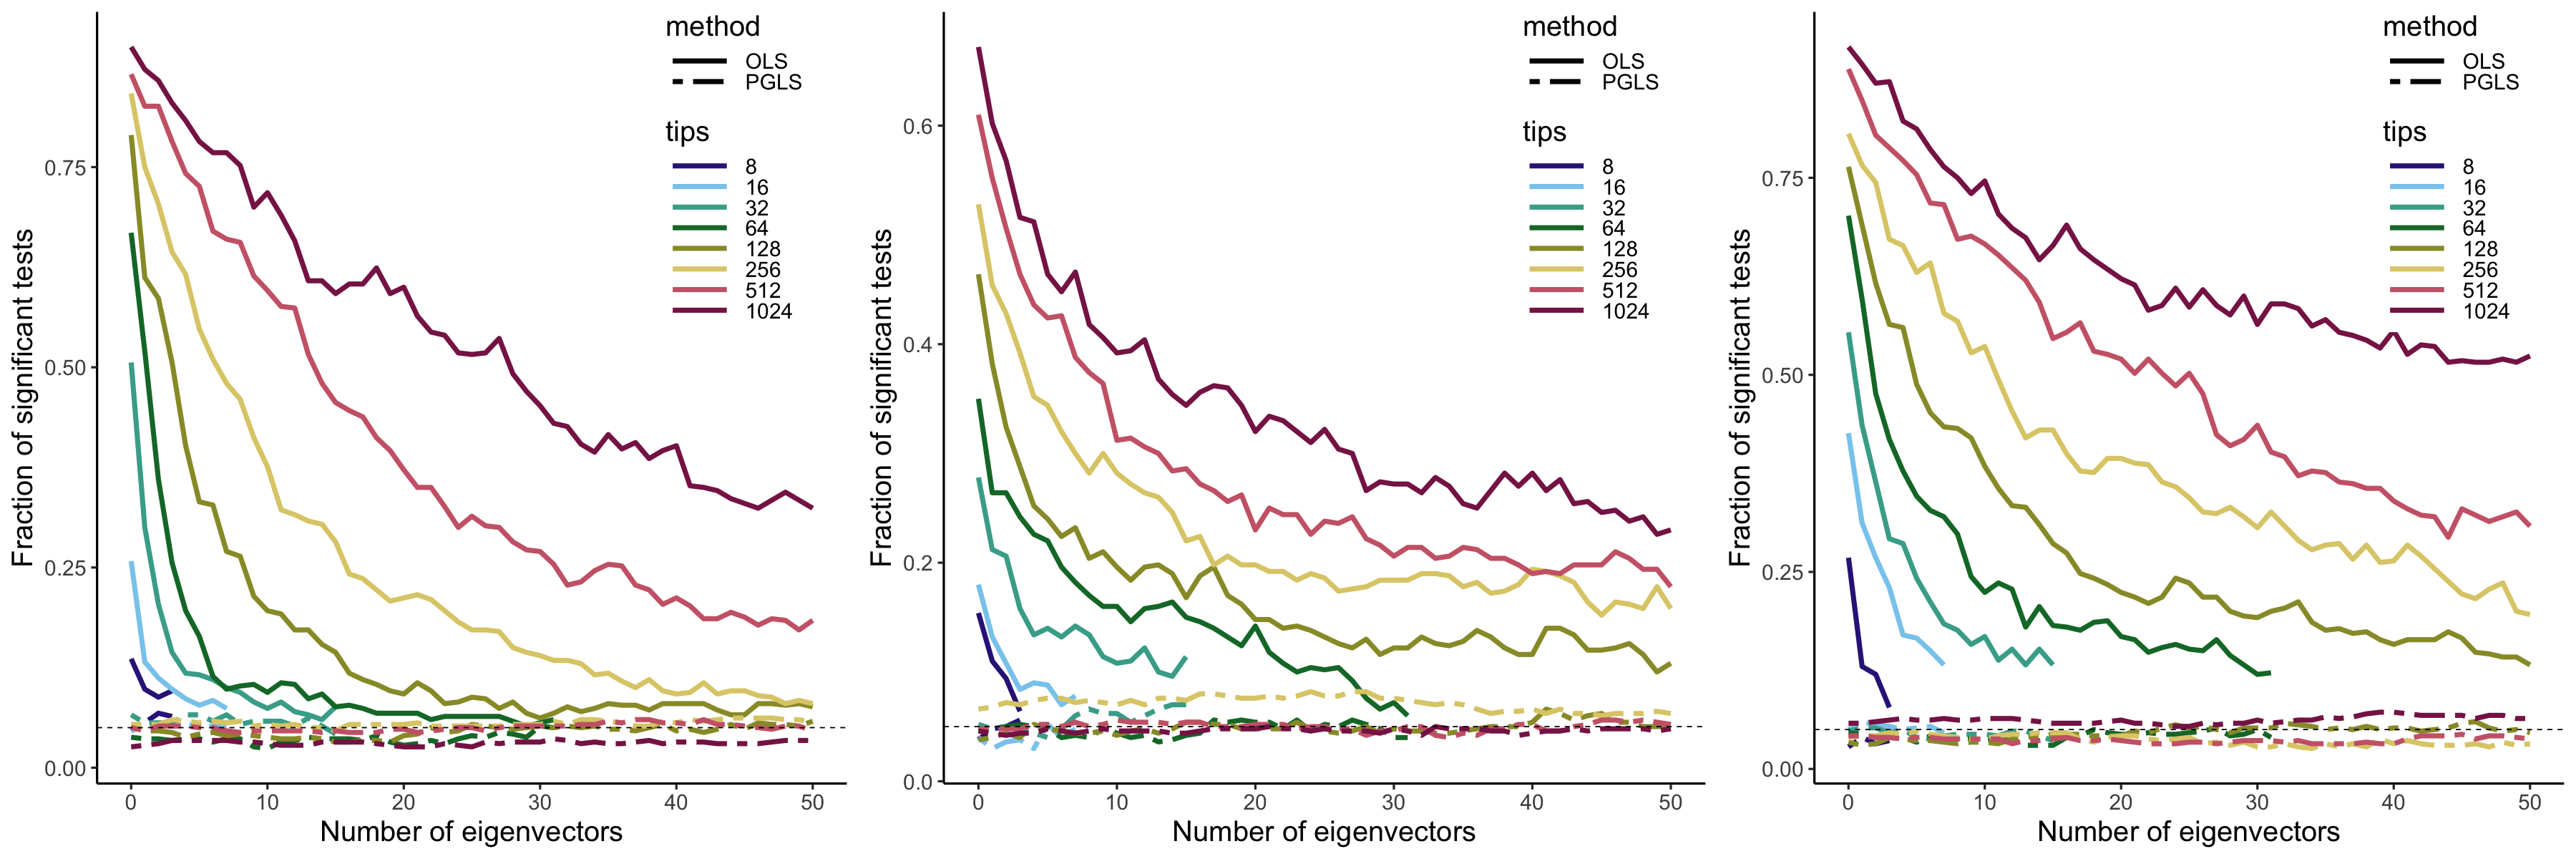

In [17]:
options(repr.plot.width = 30, repr.plot.height = 10)

row1 <- arrangeGrob(plot_1, plot_2, plot_3, ncol = 3)

# Arrange all rows into one layout
g <- grid.arrange(row1, nrow = 1)
g
ggsave("Figures_raw/Supplmentary_scaling_nonultra.pdf", g, width = 30, height = 10)
ggsave("Figures_raw/Supplmentary_scaling_nonultra.svg", g, width = 30, height = 10)